In [1]:
import numpy as np
import h5py
import chaosmagpy as cp
import sys
from os.path import dirname, join as pjoin

from matplotlib import cm
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
%config InlineBackend.figure_formats = ['png']

In [2]:
# storagedir = '/Volumes/RITCore/Env/p0306'
# datadir = pjoin(storagedir,'CHAOS_resolutionmatrices')

In [6]:
datadir = '/Users/earpwl/Datasets_no_sync/'

In [7]:
which = 'SV'

In [8]:
f = h5py.File(pjoin(datadir,f'CHAOS_Resol_1997_2026_0806_{which}.h5'),"r")

H = np.asarray(f["H"])
P = np.asarray(f["P"])
R = np.asarray(f["R"])

deriv = np.int64(f["deriv"])
dt = np.float64(f["dt"])

gnm = np.asarray(f["gnm"])

n_gnm = np.int64(f["n_gnm"])
n_spl = np.int64(f["n_spl"])
n_tp = np.int64(f["n_tp"])
nmax = np.int64(f["nmax"])


tp = np.asarray(f["tp"])

f.close()

In [44]:
#computes the right derivative gnm_deriv (as the gnm in files is always MF) 
# and the gnm_filt that passed through the resolution matrix
def resolution(gnm, P, H, R):
    gnm_spl = P @ gnm
    gnm_deriv = H @ gnm_spl #output without the matrix R.
    gnm_filt_spl = np.reshape(R @ gnm_spl.ravel('F'), gnm_spl.shape, order='F')
    gnm_filt = H @ gnm_filt_spl

    
    return gnm_deriv, gnm_filt

In [45]:
# i_gnm = 2

In [46]:
# plt.plot(gnm_deriv[:,i_gnm])
# plt.plot(gnm_filt[:,i_gnm])

In [47]:
# plt.plot(np.abs(gnm_deriv[:,i_gnm]-gnm_filt[:,i_gnm])/np.abs(gnm_deriv[:,i_gnm]))

# Synthetics

In [48]:
def mode(n,m,nmax,f,t):
    dt = t[1]-t[0]
    fs = 1/dt
    n_lm = nmax*(nmax+2)
    nt = len(t)
    out = np.zeros((nt,n_lm), dtype=np.float64)
    i_nm = 0
    for l in range(1, nmax+1):
        for k in range(l+1):
            if (l==n) & (k == np.abs(m)):
                if m < 0:
                    # print(i_nm+1)
                    out[:,i_nm+1] = np.sin(f*t)
                else:
                    out[:,i_nm] = np.sin(f*t)
                    
                    
                return out
            i_nm+=1
            if k != 0:
                i_nm+=1
    return out
    

In [49]:
fs = 1/dt
fnyq = fs/2 #Nyquist frequency

In [50]:
2*np.pi/fnyq #Nyquist period

np.float64(2.5132741228718345)

In [51]:
f = 0.9*fnyq

In [52]:
Tmode = 2*np.pi/f

In [53]:
Tmode

np.float64(2.792526803190927)

In [54]:
m1 = mode(1,0,nmax,f,tp)

In [55]:
m1_deriv, m1_res = resolution(m1, P, H, R)

In [56]:
i_gnm = 0

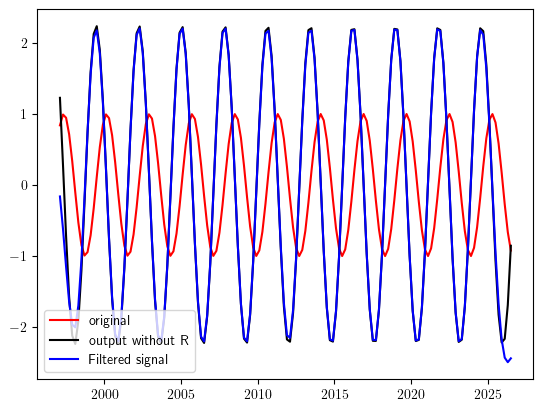

In [64]:
plt.plot(tp, m1[:,i_gnm], 'r', label='original')
plt.plot(tp, m1_deriv[:,i_gnm],'k', label='output without R')
plt.plot(tp, m1_res[:,i_gnm], 'b', label='Filtered signal')
plt.legend()

In [63]:
m1[:,i_gnm].max()

np.float64(0.999984386551392)

In [70]:
T = P @ H


In [75]:
T[0:10,2]

array([-6.54921992e-04,  5.16530158e+00, -1.62009807e+00, -1.86617547e+00,
        7.45293376e-01, -3.41605063e-01,  1.91293541e-01, -1.17723177e-01,
        7.55821963e-02, -4.93564981e-02])